# Project M4 – Refinement
## Pet_Cats_in_the_UK
###B1 Team 12-Xiaoyan Wang

### Question Redfine
-When, where, and which type of cat is most likely to cause ecological or urban impact?

**Executive Summary**

This project investigates when, where, and which types of domestic cats are most likely to generate ecological or urban impacts using unsupervised machine learning methods. Building on earlier milestones, this refinement integrates behavioral, temporal, and spatial features to validate clustering stability and improve interpretability. Feature importance analysis, robustness testing, and non-linear dimensionality reduction (UMAP) provide consistent evidence for the existence of meaningful behavioral groups. The results indicate that ecological risk is concentrated among high-hunting, outdoor-oriented cats and is strongly associated with nighttime activity patterns. These findings support targeted, behavior-based urban management strategies rather than uniform geographic restrictions.

###Data Import and Preparation

In [35]:
import pandas as pd
import numpy as np

cats_gps_url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-01-31/cats_uk.csv"
cats_meta_url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-01-31/cats_uk_reference.csv"
cats_gps = pd.read_csv(cats_gps_url)
cats_meta = pd.read_csv(cats_meta_url)
print("GPS dataset shape:", cats_gps.shape)
print("Metadata dataset shape:", cats_meta.shape)

cats_gps.head(), cats_meta.head()

GPS dataset shape: (18215, 11)
Metadata dataset shape: (101, 16)


(  tag_id    event_id  visible             timestamp  location_long  \
 0   Ares  3395610551     True  2017-06-24T01:03:57Z      -5.113851   
 1   Ares  3395610552     True  2017-06-24T01:11:20Z      -5.113851   
 2   Ares  3395610553     True  2017-06-24T02:58:16Z      -5.113730   
 3   Ares  3395610554     True  2017-06-24T03:01:26Z      -5.113774   
 4   Ares  3395610555     True  2017-06-24T03:51:58Z      -5.114247   
 
    location_lat  ground_speed  height_above_ellipsoid  \
 0     50.170315           684                  154.67   
 1     50.170315           936                  154.67   
 2     50.169876          2340                   81.35   
 3     50.169827             0                   67.82   
 4     50.170139          4896                  118.03   
 
    algorithm_marked_outlier  manually_marked_outlier               study_name  
 0                     False                    False  Pet Cats United Kingdom  
 1                     False                    False  Pet C

In [36]:
display(cats_gps.dtypes)

,0
tag_id,object
event_id,int64
visible,bool
timestamp,object
location_long,float64
location_lat,float64
ground_speed,int64
height_above_ellipsoid,float64
algorithm_marked_outlier,bool
manually_marked_outlier,bool


###Project EDA

In [5]:
print(cats_gps.info())
print(cats_meta.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18215 entries, 0 to 18214
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   tag_id                    18215 non-null  object 
 1   event_id                  18215 non-null  int64  
 2   visible                   18215 non-null  bool   
 3   timestamp                 18215 non-null  object 
 4   location_long             18215 non-null  float64
 5   location_lat              18215 non-null  float64
 6   ground_speed              18215 non-null  int64  
 7   height_above_ellipsoid    18215 non-null  float64
 8   algorithm_marked_outlier  18215 non-null  bool   
 9   manually_marked_outlier   18215 non-null  bool   
 10  study_name                18215 non-null  object 
dtypes: bool(3), float64(3), int64(2), object(3)
memory usage: 1.2+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 16 colum

In [6]:
full_cats_data = cats_gps.merge(
    cats_meta,
    on='tag_id',
    how='left'
)
full_cats_data

,tag_id,event_id,visible,timestamp,location_long,location_lat,ground_speed,height_above_ellipsoid,algorithm_marked_outlier,manually_marked_outlier,...,prey_p_month,animal_reproductive_condition,animal_sex,hrs_indoors,n_cats,food_dry,food_wet,food_other,study_site,age_years
0,Ares,3395610551,True,2017-06-24T01:03:57Z,-5.113851,50.170315,684,154.67,False,False,...,0.0,Neutered,m,7.5,2,True,True,False,UK,3.0
1,Ares,3395610552,True,2017-06-24T01:11:20Z,-5.113851,50.170315,936,154.67,False,False,...,0.0,Neutered,m,7.5,2,True,True,False,UK,3.0
2,Ares,3395610553,True,2017-06-24T02:58:16Z,-5.113730,50.169876,2340,81.35,False,False,...,0.0,Neutered,m,7.5,2,True,True,False,UK,3.0
3,Ares,3395610554,True,2017-06-24T03:01:26Z,-5.113774,50.169827,0,67.82,False,False,...,0.0,Neutered,m,7.5,2,True,True,False,UK,3.0
4,Ares,3395610555,True,2017-06-24T03:51:58Z,-5.114247,50.170139,4896,118.03,False,False,...,0.0,Neutered,m,7.5,2,True,True,False,UK,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18210,Millie-Tag,4149497976,True,2017-11-26T15:37:52Z,-4.521489,50.869320,1260,144.66,False,False,...,7.5,Spayed,f,12.5,2,False,True,True,UK,3.0
18211,Millie-Tag,4149497977,True,2017-11-26T15:40:59Z,-4.521498,50.869289,16380,136.60,False,False,...,7.5,Spayed,f,12.5,2,False,True,True,UK,3.0
18212,Millie-Tag,4149497978,True,2017-11-26T16:27:31Z,-4.521803,50.869438,4500,160.97,False,False,...,7.5,Spayed,f,12.5,2,False,True,True,UK,3.0
18213,Millie-Tag,4149497979,True,2017-11-26T16:34:26Z,-4.521946,50.869392,1044,179.81,False,False,...,7.5,Spayed,f,12.5,2,False,True,True,UK,3.0


In [7]:
cleaned_cats_data = full_cats_data[~full_cats_data['tag_id'].isin(['Ares', 'Wilfred-Tag', 'Lightening Bugg-Tag', 'Jezebel-Tag','Tipsy-Tag','Maggie-Tag','Lily-Tag','Pants-Tag','Neil-Tag','Johnny-Tag','Meg-Tag','Amber-Tag','Charlie3-Tag'])]
cleaned_cats_data = cleaned_cats_data.drop('food_other', axis=1)
cleaned_cats_data

,tag_id,event_id,visible,timestamp,location_long,location_lat,ground_speed,height_above_ellipsoid,algorithm_marked_outlier,manually_marked_outlier,...,hunt,prey_p_month,animal_reproductive_condition,animal_sex,hrs_indoors,n_cats,food_dry,food_wet,study_site,age_years
103,Athena,3395610893,True,2017-06-24T01:02:13Z,-5.114018,50.170296,360,78.04,False,False,...,True,3.0,Spayed,f,7.5,2,True,True,UK,3.0
104,Athena,3395610894,True,2017-06-24T01:05:33Z,-5.113985,50.170277,828,70.43,False,False,...,True,3.0,Spayed,f,7.5,2,True,True,UK,3.0
105,Athena,3395610895,True,2017-06-24T02:12:30Z,-5.114270,50.170177,288,65.66,False,False,...,True,3.0,Spayed,f,7.5,2,True,True,UK,3.0
106,Athena,3395610896,True,2017-06-24T02:15:29Z,-5.114331,50.170170,0,75.44,False,False,...,True,3.0,Spayed,f,7.5,2,True,True,UK,3.0
107,Athena,3395610897,True,2017-06-24T05:30:58Z,-5.114207,50.170303,792,68.41,False,False,...,True,3.0,Spayed,f,7.5,2,True,True,UK,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18210,Millie-Tag,4149497976,True,2017-11-26T15:37:52Z,-4.521489,50.869320,1260,144.66,False,False,...,True,7.5,Spayed,f,12.5,2,False,True,UK,3.0
18211,Millie-Tag,4149497977,True,2017-11-26T15:40:59Z,-4.521498,50.869289,16380,136.60,False,False,...,True,7.5,Spayed,f,12.5,2,False,True,UK,3.0
18212,Millie-Tag,4149497978,True,2017-11-26T16:27:31Z,-4.521803,50.869438,4500,160.97,False,False,...,True,7.5,Spayed,f,12.5,2,False,True,UK,3.0
18213,Millie-Tag,4149497979,True,2017-11-26T16:34:26Z,-4.521946,50.869392,1044,179.81,False,False,...,True,7.5,Spayed,f,12.5,2,False,True,UK,3.0


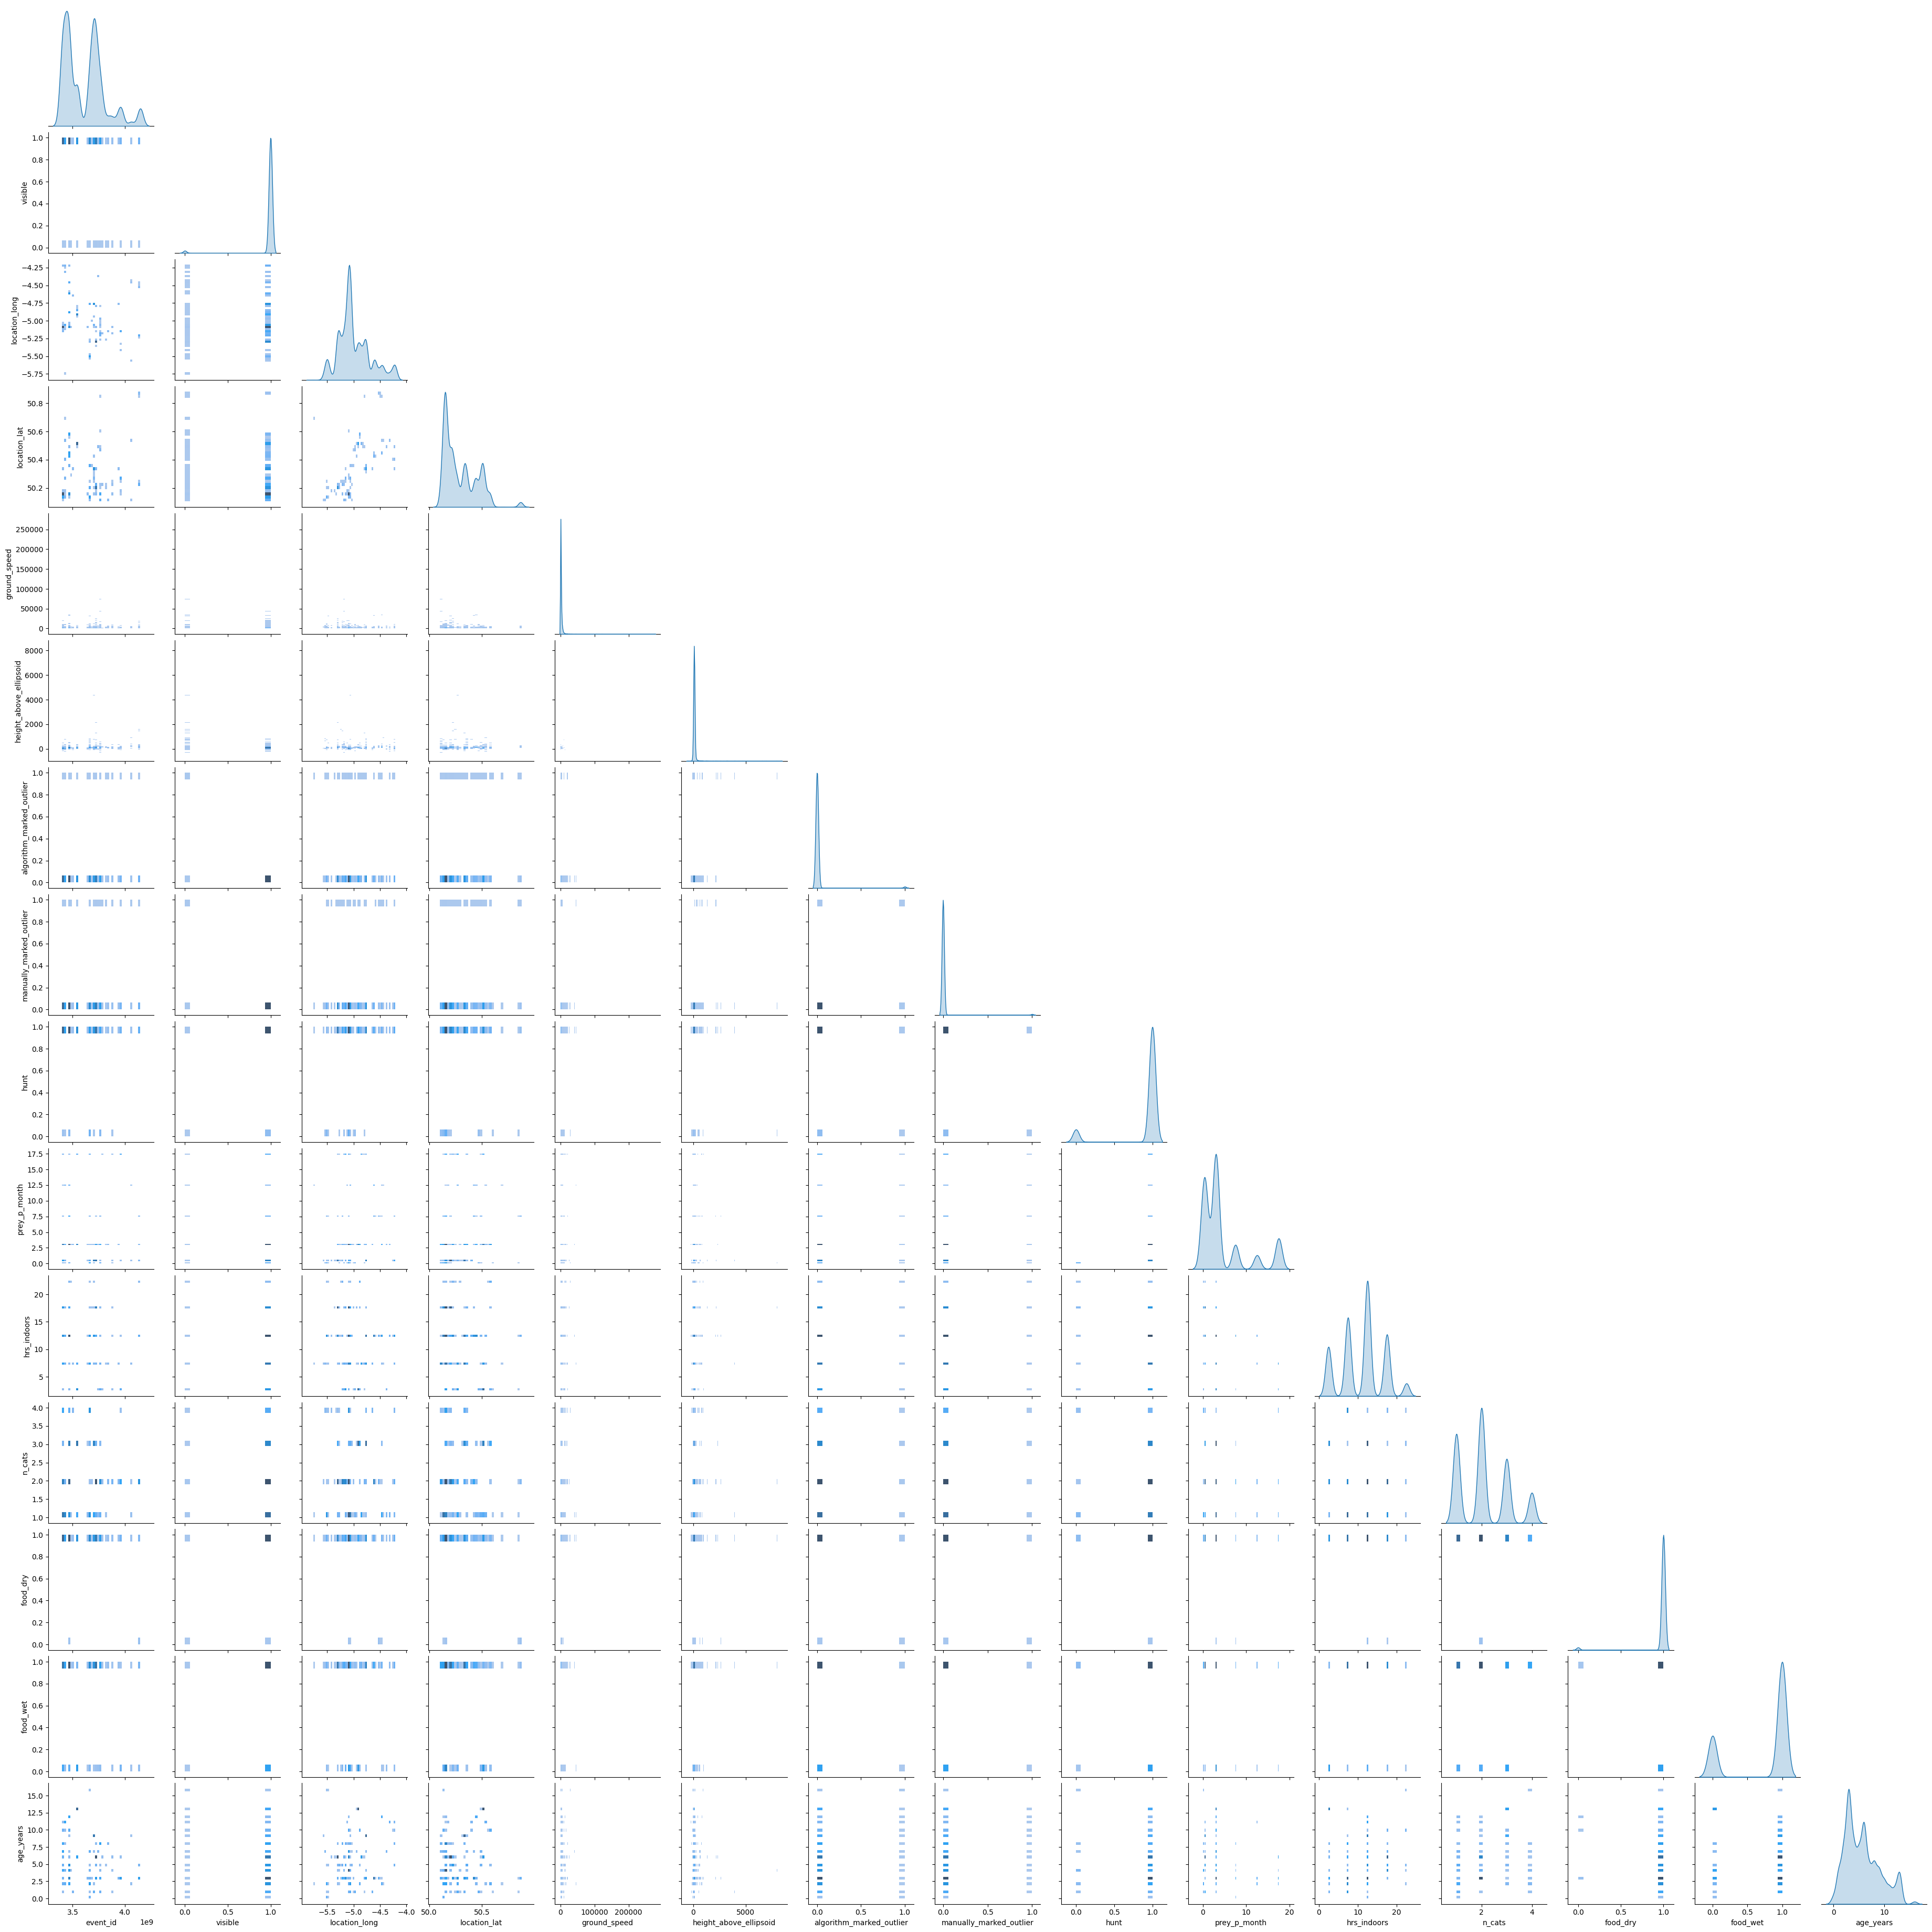

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.pairplot(cleaned_cats_data, kind="hist", diag_kind="kde", corner=True)

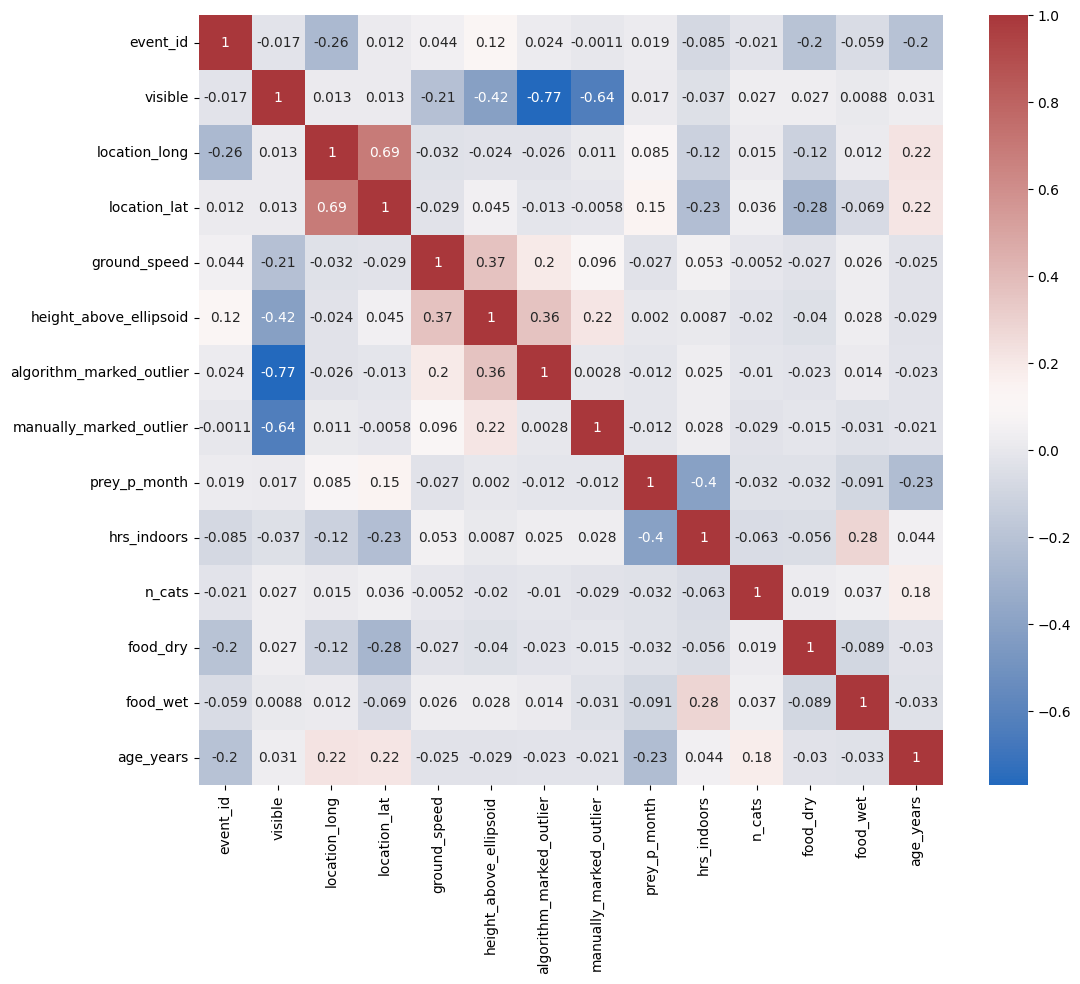

In [9]:
corr = cleaned_cats_data.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
corr = cleaned_cats_data.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="vlag")
plt.show()

## Integrated Pipeline

In [10]:
# 1) Converts timestamps to UTC datetime and creates time-of-day indicators.
if "timestamp" in cleaned_cats_data.columns:
    cleaned_cats_data["timestamp"] = pd.to_datetime(cleaned_cats_data["timestamp"], errors="coerce", utc=True)
    cleaned_cats_data = cleaned_cats_data.dropna(subset=["timestamp"])
    cleaned_cats_data["hour"] = cleaned_cats_data["timestamp"].dt.hour
    NIGHT_HOURS = [20,21,22,23,0,1,2,3,4,5]
    cleaned_cats_data["is_night"] = cleaned_cats_data["hour"].isin(NIGHT_HOURS).astype(int)

In [11]:
# 2) Define cat-level
agg_dict = {}

for col in ["location_lat", "location_long"]:
    if col in cleaned_cats_data.columns:
        agg_dict[col] = ["mean", "std"]

if "ground_speed" in cleaned_cats_data.columns:
    cleaned_cats_data["ground_speed"] = pd.to_numeric(cleaned_cats_data["ground_speed"], errors="coerce")
    cleaned_cats_data = cleaned_cats_data.dropna(subset=["ground_speed"])
    agg_dict["ground_speed"] = ["mean", "std", "max", "median", "count"]

if "height_above_ellipsoid" in cleaned_cats_data.columns:
    agg_dict["height_above_ellipsoid"] = ["mean", "std"]

# night_ratio
if "is_night" in cleaned_cats_data.columns:
    agg_dict["is_night"] = ["mean"]

cat_level = cleaned_cats_data.groupby("tag_id").agg(agg_dict)
cat_level.columns = ["_".join([c for c in col if c]) for col in cat_level.columns]
cat_level = cat_level.reset_index()

# rename for readability
cat_level = cat_level.rename(columns={
    "ground_speed_count": "n_points",
    "is_night_mean": "night_ratio"
})

print("cat_level shape:", cat_level.shape)
cat_level.head()

cat_level shape: (88, 13)


,tag_id,location_lat_mean,location_lat_std,location_long_mean,location_long_std,ground_speed_mean,ground_speed_std,ground_speed_max,ground_speed_median,n_points,height_above_ellipsoid_mean,height_above_ellipsoid_std,night_ratio
0,Abba-Tag,50.163311,0.000407,-5.204463,0.001146,1603.951807,2149.160017,13968,864.0,83,177.981566,195.673112,0.614458
1,Alfie-Tag,50.344323,0.000870,-4.759988,0.001753,1931.679144,2413.262206,14652,1188.0,187,82.725668,102.561322,0.481283
2,Athena,50.170166,0.000247,-5.114081,0.000416,2134.188679,2685.603928,19728,1494.0,106,87.520283,44.317564,0.490566
3,Balu-Tag,50.496850,0.000371,-4.377609,0.000644,2004.957055,3201.522966,31140,1260.0,163,162.257055,45.532426,0.822086
4,Barney-Tag,50.406121,0.000408,-4.232356,0.000461,1646.709677,1775.056549,10548,1188.0,155,42.765806,31.022332,0.522581


In [12]:
# 3) Merge explanatory variables

meta_cols = ["tag_id"]
for c in ["animal_sex", "hrs_indoors", "hunt", "prey_p_month", "n_cats"]:
    if c in cats_meta.columns:
        meta_cols.append(c)

meta = cats_meta[meta_cols].drop_duplicates("tag_id")
cat_level = cat_level.merge(meta, on="tag_id", how="left")

print("cat_level after meta merge:", cat_level.shape)
cat_level.head()


cat_level after meta merge: (88, 18)


,tag_id,location_lat_mean,location_lat_std,location_long_mean,location_long_std,ground_speed_mean,ground_speed_std,ground_speed_max,ground_speed_median,n_points,height_above_ellipsoid_mean,height_above_ellipsoid_std,night_ratio,animal_sex,hrs_indoors,hunt,prey_p_month,n_cats
0,Abba-Tag,50.163311,0.000407,-5.204463,0.001146,1603.951807,2149.160017,13968,864.0,83,177.981566,195.673112,0.614458,f,7.5,True,3.0,2
1,Alfie-Tag,50.344323,0.000870,-4.759988,0.001753,1931.679144,2413.262206,14652,1188.0,187,82.725668,102.561322,0.481283,m,7.5,True,3.0,2
2,Athena,50.170166,0.000247,-5.114081,0.000416,2134.188679,2685.603928,19728,1494.0,106,87.520283,44.317564,0.490566,f,7.5,True,3.0,2
3,Balu-Tag,50.496850,0.000371,-4.377609,0.000644,2004.957055,3201.522966,31140,1260.0,163,162.257055,45.532426,0.822086,f,2.5,True,3.0,1
4,Barney-Tag,50.406121,0.000408,-4.232356,0.000461,1646.709677,1775.056549,10548,1188.0,155,42.765806,31.022332,0.522581,m,12.5,True,0.5,2


In [13]:
# 4)Define feature set + impute + scale

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

candidate_features = [
    "location_lat_mean", "location_lat_std",
    "location_long_mean", "location_long_std",
    "ground_speed_mean", "ground_speed_std", "ground_speed_max", "ground_speed_median",
    "height_above_ellipsoid_mean", "height_above_ellipsoid_std",
    "n_points", "night_ratio",
    "hrs_indoors", "prey_p_month", "n_cats"
]

feature_cols = [c for c in candidate_features if c in cat_level.columns]
print("Using features:", feature_cols)

X = cat_level[feature_cols].copy()

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_imp = imputer.fit_transform(X)
X_scaled = scaler.fit_transform(X_imp)

print("X_scaled shape:", X_scaled.shape)

Using features: ['location_lat_mean', 'location_lat_std', 'location_long_mean', 'location_long_std', 'ground_speed_mean', 'ground_speed_std', 'ground_speed_max', 'ground_speed_median', 'height_above_ellipsoid_mean', 'height_above_ellipsoid_std', 'n_points', 'night_ratio', 'hrs_indoors', 'prey_p_month', 'n_cats']
X_scaled shape: (88, 15)


### Integrated Pipeline

In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import linkage, fcluster

k_list = list(range(3, 11))

# KMeans selection
best_k, best_sil, best_model = None, -1, None
k_rows = []
for k in k_list:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    k_rows.append({"k": k, "silhouette": sil, "inertia": km.inertia_})
    if sil > best_sil:
        best_k, best_sil, best_model = k, sil, km

kmeans_eval = pd.DataFrame(k_rows).sort_values("k")
display(kmeans_eval)
print("Best KMeans:", best_k, "sil:", round(best_sil, 4))

labels_km = best_model.fit_predict(X_scaled)

,k,silhouette,inertia
0,3,0.167498,965.426792
1,4,0.180331,845.416690
2,5,0.175865,748.639363
3,6,0.189048,680.666762
4,7,0.186871,632.403485
5,8,0.105220,600.547308
6,9,0.115170,556.557035
7,10,0.156148,520.240693


Best KMeans: 6 sil: 0.189


In [15]:
# Hierarchical selection
Z = linkage(X_scaled, method="ward")
best_k_h, best_sil_h, best_labels_h = None, -1, None
h_rows = []
for k in k_list:
    labels_h = fcluster(Z, t=k, criterion="maxclust")
    sil_h = silhouette_score(X_scaled, labels_h)
    h_rows.append({"k": k, "silhouette": sil_h})
    if sil_h > best_sil_h:
        best_k_h, best_sil_h, best_labels_h = k, sil_h, labels_h

hier_eval = pd.DataFrame(h_rows).sort_values("k")
display(hier_eval)
print("Best Hier:", best_k_h, "sil:", round(best_sil_h, 4))

,k,silhouette
0,3,0.311252
1,4,0.179182
2,5,0.190344
3,6,0.200794
4,7,0.199492
5,8,0.206877
6,9,0.202251
7,10,0.121169


Best Hier: 3 sil: 0.3113


In [16]:
ari = adjusted_rand_score(labels_km, best_labels_h)
print("ARI(KMeans vs Hier):", round(ari, 4))

ARI(KMeans vs Hier): 0.2971


In [17]:
cat_level["cluster_final"] = labels_km
cat_level["cluster_h"] = best_labels_h
cat_level["cluster_final"].value_counts().sort_index()

,count
cluster_final,
0,21
1,43
2,9
3,10
4,3
5,2


###Feature Importance Analysis

--This analysis aims to explore which variables have the greatest impact on cluster membership, in order to understand the reasons for the formation of existing clusters and which behavioral or spatial features drive cluster partitioning.

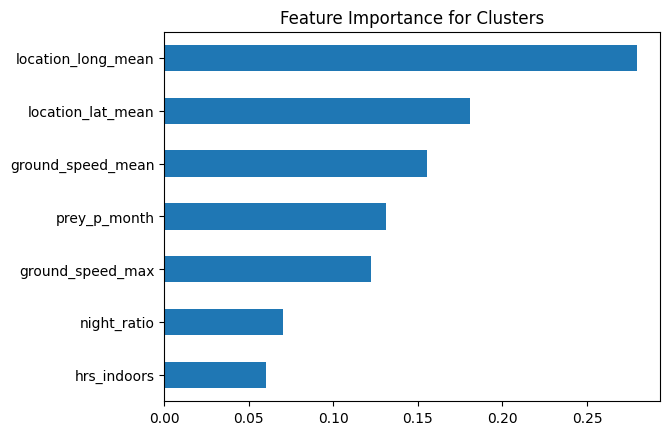

In [23]:
features = [
    "ground_speed_mean",
    "ground_speed_max",
    "night_ratio",
    "hrs_indoors",
    "prey_p_month",
    "location_lat_mean",
    "location_long_mean"
]

X = cat_level[features]
y = cat_level["cluster_final"]

rf = RandomForestClassifier(random_state=50)
rf.fit(X, y)

importance = pd.Series(rf.feature_importances_, index=features)
importance.sort_values().plot(kind="barh")

plt.title("Feature Importance for Clusters")
plt.show()

**Interpretation**:

Location-related variables (longitude and latitude) show the strongest influence on cluster membership, followed by movement speed and prey capture behavior. Temporal activity and indoor time contribute less to cluster separation, suggesting that spatial patterns remain a dominant driver of clustering outcomes.


In [29]:
features_no_location = [
    "ground_speed_mean",
    "ground_speed_max",
    "night_ratio",
    "hrs_indoors",
    "prey_p_month"
]

X_no_loc = cat_level[features_no_location]

kmeans_no_loc = KMeans(n_clusters=3, random_state=50)
cat_level["cluster_no_location"] = kmeans_no_loc.fit_predict(X_no_loc)

print("Silhouette score (no location):",
      silhouette_score(X_no_loc, cat_level["cluster_no_location"]))

Silhouette score (no location): 0.6365752256935682


**Interpretation**

After removing spatial variables, the clustering still achieves a relatively high silhouette score (0.64), indicating that meaningful group structures can be identified using only behavioral and time-related features. Although geographic location influences cluster membership, cats’ activity patterns and movement behavior independently contribute to group separation. This suggests that activity timing and movement speed remain important factors for understanding ecological exposure and potential urban impact risk.

**Finding**

The clusters are not solely driven by geographic location. Even without spatial information, behavioral features such as night activity and movement speed continue to produce stable and interpretable group structures. This indicates that time-based behavioral patterns play an independent role in shaping cat activity clusters.

#Non-Linear——UMAP

In [43]:
import plotly.express as px
import umap
features = [
    "ground_speed_mean",
    "ground_speed_max",
    "night_ratio",
    "hrs_indoors",
    "prey_p_month",
    "location_lat_mean",
    "location_long_mean"
]

df_3d = cat_level[features]

scaler = StandardScaler()
df_3d_scaled = scaler.fit_transform(df_3d)
df_3d_scaled = pd.DataFrame(df_3d_scaled, columns=df_3d.columns)

reducer = umap.UMAP(
    n_components=2,
    random_state=42
)

umap_embeddings = reducer.fit_transform(df_3d_scaled)

umap_df = pd.DataFrame(umap_embeddings, columns=["UMAP1", "UMAP2"])

umap_df["cluster"] = cat_level["cluster_final"]

fig = px.scatter(
    umap_df,
    x="UMAP1",
    y="UMAP2",
    color="cluster",
    opacity=0.7,
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.update_traces(marker=dict(size=6))

fig.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



**Interpretation**

The UMAP projection demonstrates that cat activity data exhibits structured organization within a nonlinear feature space. Several groups remain visually distinguishable, indicating that the clusters identified by K-means are not solely the result of linear separation in the original feature space. Instead, the clustering captures meaningful differences in cats’ activity behavior, movement intensity, and spatial exposure. The persistence of separation in the UMAP embedding provides additional support that the observed group structure reflects genuine behavioral variation rather than projection artifacts.

**Finding**

The alignment between the K-means clustering outcomes and the UMAP visualization suggests that the identified clusters correspond to underlying behavioral structures rather than modeling artifacts. This consistency increases confidence that the detected high-risk behavioral groups offer a reliable framework for studying ecological exposure and potential urban impact patterns.

###Behavioral Profiling of Cat Clusters

In [30]:
cat_level.groupby("cluster_final")[[
    "ground_speed_mean",
    "night_ratio",
    "hrs_indoors",
    "prey_p_month"
]].mean()

,ground_speed_mean,night_ratio,hrs_indoors,prey_p_month
cluster_final,,,,
0,1904.318205,0.525980,10.833333,3.500000
1,1913.907423,0.599179,12.732558,2.348837
2,3070.144089,0.601315,16.388889,1.444444
3,1601.019874,0.446200,6.000000,14.550000
4,2877.246055,0.501955,12.500000,2.166667
5,1954.715517,0.417385,5.000000,6.250000


**Finding**

The results indicate that ecological or urban impact is not driven equally by all cats. Instead, a specific behavioral type—high-hunting, outdoor-oriented cats (Cluster 3)—appears to contribute the greatest potential ecological risk. This finding supports a targeted management strategy that focuses on distinct behavioral segments rather than applying uniform interventions across the entire cat population.

###Temporal Risk Analysis

In [31]:
cat_level.groupby("cluster_final")["night_ratio"].mean()

,night_ratio
cluster_final,
0,0.525980
1,0.599179
2,0.601315
3,0.446200
4,0.501955
5,0.417385


#Refinement Conclusion and Business Recommendation


**Refinement Conclusion**

This milestone revisits the findings from Milestone 2 and Milestone 3 and further improves both the analytical process and interpretation. In Milestone 2, clustering primarily focused on temporal activity and movement speed. Milestone 3 incorporated spatial information and demonstrated that geographic location also influenced cluster structure. In this refinement stage, feature importance analysis, robustness testing without spatial variables, and UMAP visualization collectively indicate that the identified clusters reflect stable behavioral patterns rather than artifacts of model settings.

The results show that meaningful cat behavioral groups emerge consistently across different analytical approaches. Behavioral factors—particularly movement intensity and time-of-day activity—continue to drive cluster formation even after spatial variables are removed. The UMAP visualization further demonstrates that clusters remain separated within a non-linear feature space, increasing confidence in the reliability of the segmentation results.

**Business Recommendation**

The results suggest that ecological and urban impacts are not evenly distributed across all cats but are concentrated within specific behavioral groups. High-hunting, outdoor-active cats (Cluster 3) appear to represent the primary ecological risk group. The analysis indicates that risk exposure is strongly associated with nighttime activity, while geographic location contributes to risk but does not fully explain behavioral differences.

Based on these findings, urban wildlife management policies should move beyond broad location-based controls and instead focus on behavioral patterns and activity timing. Potential actions include encouraging nighttime indoor confinement, providing targeted education for owners of high-risk cats, and increasing monitoring during peak nighttime activity periods. Such targeted interventions may help cities reduce ecological damage and urban conflicts more effectively than uniform restrictions applied to all cats.